In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [3]:
print("numpy", np.__version__)
print("pandas", pd.__version__)
print("seaborn", sns.__version__)
print("sklearn",sklearn.__version__)

numpy 2.0.2
pandas 2.2.2
seaborn 0.13.2
sklearn 1.6.1


In [5]:
# load data
train = pd.read_csv("/content/train_u6lujuX_CVtuZ9i.csv")
test  = pd.read_csv("/content/test_Y3wMUE5_7gLdaTN.csv")

# basic checks
print("Train shape:", train.shape)
print("Test shape:", test.shape)

train.head()

Train shape: (614, 13)
Test shape: (367, 12)


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [6]:
train.isnull().sum()

,0
Loan_ID,0
Gender,13
Married,3
Dependents,15
Education,0
Self_Employed,32
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,22
Loan_Amount_Term,14


In [7]:
train['Loan_Status'].value_counts()

,count
Loan_Status,
Y,422
N,192


In [8]:
train['Loan_Status'].value_counts(normalize=True)

,proportion
Loan_Status,
Y,0.687296
N,0.312704


In [9]:
# Categorical columns
train['Gender'].fillna(train['Gender'].mode()[0], inplace=True)
train['Married'].fillna(train['Married'].mode()[0], inplace=True)
train['Dependents'] = train['Dependents'].replace('3+', 3).astype(float)
#train['Dependents'].fillna(train['Dependents'].mode()[0], inplace=True)
train['Self_Employed'].fillna(train['Self_Employed'].mode()[0], inplace=True)

# Numerical columns
train['LoanAmount'].fillna(train['LoanAmount'].median(), inplace=True)
train['Loan_Amount_Term'].fillna(train['Loan_Amount_Term'].mode()[0], inplace=True)
train['Credit_History'].fillna(train['Credit_History'].mode()[0], inplace=True)


/tmp/ipython-input-1792522185.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train['Gender'].fillna(train['Gender'].mode()[0], inplace=True)
/tmp/ipython-input-1792522185.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace

In [10]:
# Encode categorical variables
train['Gender'] = train['Gender'].map({'Male': 1, 'Female': 0})
train['Married'] = train['Married'].map({'Yes': 1, 'No': 0})
train['Education'] = train['Education'].map({'Graduate': 1, 'Not Graduate': 0})
train['Self_Employed'] = train['Self_Employed'].map({'Yes': 1, 'No': 0})
train['Loan_Status'] = train['Loan_Status'].map({'Y': 1, 'N': 0})


In [11]:
# Total Income
train['Total_Income'] = train['ApplicantIncome'] + train['CoapplicantIncome']

# Log transform skewed features
train['LoanAmount_log'] = np.log(train['LoanAmount'])
train['Total_Income_log'] = np.log(train['Total_Income'])

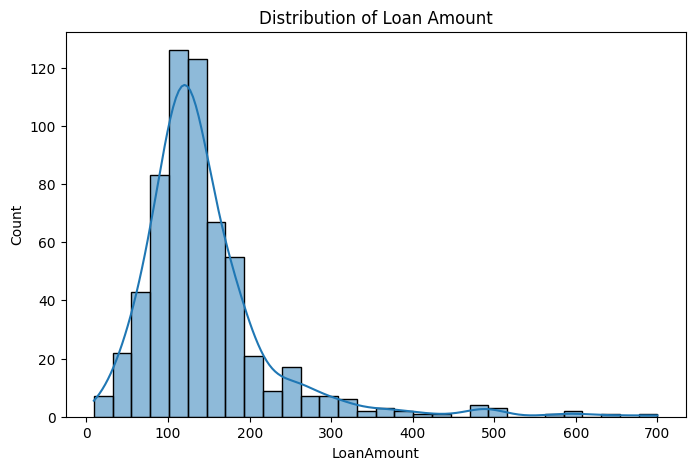

In [12]:
plt.figure(figsize=(8,5))
sns.histplot(train['LoanAmount'], bins=30, kde=True)
plt.title('Distribution of Loan Amount')
plt.show()

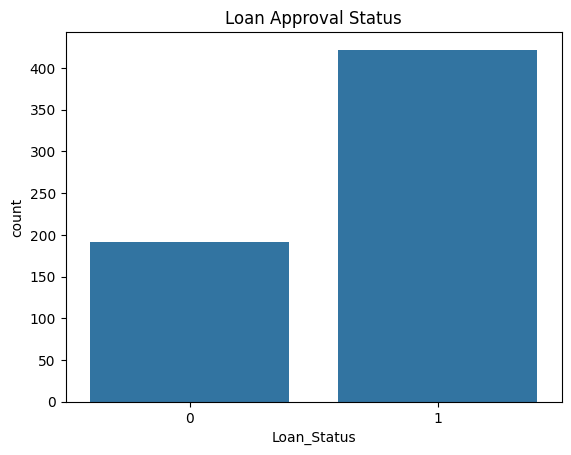

In [13]:
sns.countplot(x='Loan_Status', data=train)
plt.title('Loan Approval Status')
plt.show()

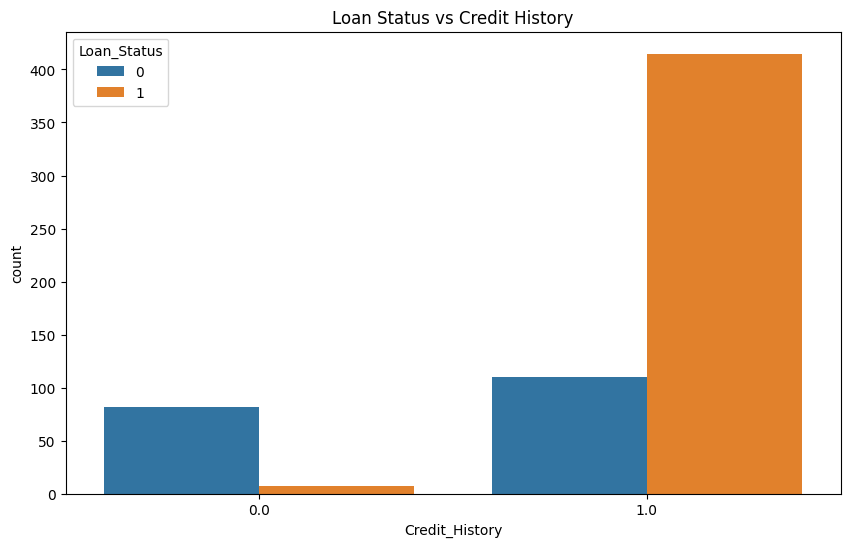

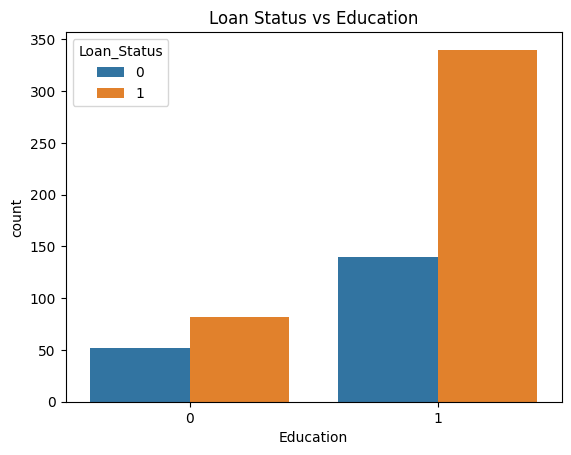

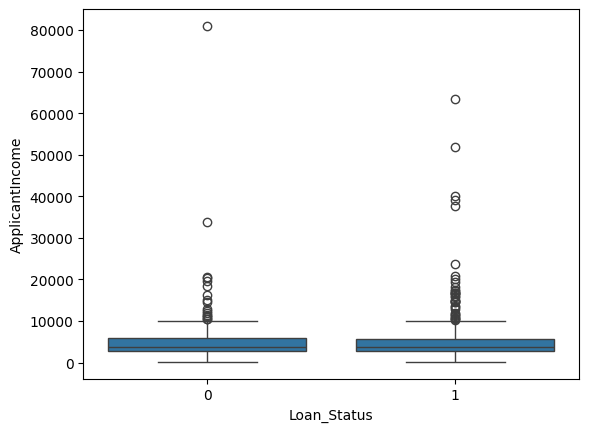

In [14]:
plt.figure(figsize=(10,6))
sns.countplot(x='Credit_History', hue='Loan_Status', data=train)
plt.title('Loan Status vs Credit History')
plt.show()

sns.countplot(x='Education', hue='Loan_Status', data=train)
plt.title('Loan Status vs Education')
plt.show()

sns.boxplot(x='Loan_Status', y='ApplicantIncome', data=train)
plt.show()

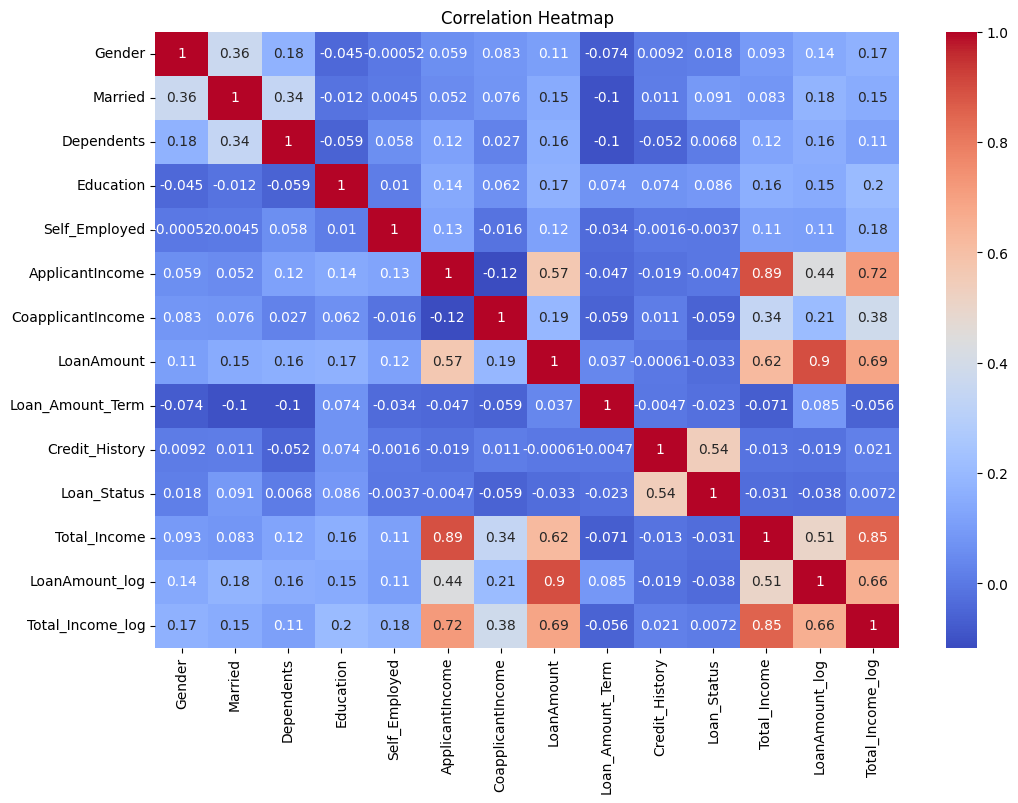

In [15]:
plt.figure(figsize=(12,8))
sns.heatmap(train.select_dtypes(include=[np.number]).corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [16]:
# Features (exclude Loan_ID and target)
X = train[['Gender', 'Married', 'Education', 'Self_Employed', 'Dependents',
           'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
           'Loan_Amount_Term', 'Credit_History', 'Total_Income',
           'LoanAmount_log', 'Total_Income_log']]

# Target
y = train['Loan_Status']


In [17]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [18]:
# Create Random Forest model
rf_model = RandomForestClassifier(
    n_estimators=100,      # Number of trees
    random_state=42
)


In [19]:
rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [20]:
y_pred = rf_model.predict(X_val)

print("Accuracy:", accuracy_score(y_val, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_val, y_pred))
print("Classification Report:\n", classification_report(y_val, y_pred))

Accuracy: 0.7804878048780488
Confusion Matrix:
 [[22 21]
 [ 6 74]]
Classification Report:
               precision    recall  f1-score   support

           0       0.79      0.51      0.62        43
           1       0.78      0.93      0.85        80

    accuracy                           0.78       123
   macro avg       0.78      0.72      0.73       123
weighted avg       0.78      0.78      0.77       123



In [21]:

import joblib
joblib.dump(rf_model, "loan_model.pkl")

['loan_model.pkl']

In [22]:
print("joblib", joblib.__version__)

joblib 1.5.3
